# Lab 5 Report:
## Create Arthur Conan Doyle AI with RNN

### Nate Chaoweeraprasit

In [54]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.distributions import Categorical

In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
from IPython.display import Image # For displaying images in colab jupyter cell

## Prepare Data

In [57]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cuda")
print(device)

# You will train on the first N characters of the Sherlock Holmes book
# Pick the size of your training data, i.e. N
data_size_to_train = 50000

# Load the Sherlock Holmes data up to data_size_to_train
data = open('/content/drive/MyDrive/phys 417/lab_05/sherlock.txt', 'r').read()[:data_size_to_train]

# Find the set of unique characters within the training data
characters = sorted(list(set(data)))

# total number of characters in the training data and number of unique characters
data_size, vocab_size = len(data), len(characters)

print("Data has {} characters, {} unique".format(data_size, vocab_size))

cuda
Data has 50000 characters, 73 unique


In [58]:
# Use Python Dictionary to map the characters to numbers and vice versa
# one hot?
char_to_num = { ch:i for i,ch in enumerate(characters) }
num_to_char = { i:ch for i,ch in enumerate(characters) }

In [59]:
# Use the character_to_num dictionary to map each character in the training dataset to a number
data = list(data)

for i, ch in enumerate(data):
    data[i] = char_to_num[ch]

print(data[:10])

[0, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## Define Model

In [60]:
class CharRNN(torch.nn.Module):

    def __init__(self, num_embeddings, embedding_dim, input_size, hidden_size, num_layers, output_size):

        super(CharRNN, self).__init__()

        # map char integers to vectors
        self.embedding = torch.nn.Embedding(num_embeddings, embedding_dim)

        # set up core RNN layer with relu activation
        self.rnn = torch.nn.RNN(input_size=input_size, hidden_size=hidden_size,
                                num_layers=num_layers,
                                nonlinearity = 'relu')

        # remap hidden state
        self.decoder = torch.nn.Linear(hidden_size, output_size)

    def forward(self, input_seq, hidden_state):

        # step input char index through embedding layer
        embedding = self.embedding(input_seq)

        # step embeddings + hidden state through RNN
        output, hidden_state = self.rnn(embedding, hidden_state)

        # convert output into character scores (to eval which char to print next)
        output = self.decoder(output)

        # return output char prediction + hidden state
        return output, hidden_state.detach()

## Define Hyperparameters

In [61]:
# Fix random seed
torch.manual_seed(25)

# Define RNN network
rnn = CharRNN(num_embeddings = vocab_size,
              embedding_dim = 128,
              input_size = 128,
              hidden_size = 512,
              num_layers = 2,
              output_size=vocab_size)

# Define learning rate and epochs
learning_rate = 0.001
epochs = 100

# Size of the input sequence to be used during training and validation
training_sequence_len = 100
validation_sequence_len = 250

# Define loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(rnn.parameters(), lr=learning_rate)

# add .cuda() for GPU acceleration
rnn = rnn.to(device)

## Identify Tracked Values

In [62]:
# Tracking training loss per each input/target sequence fwd/bwd pass
training_loss = []

## Train Model

In [63]:
data = torch.unsqueeze(torch.tensor(data), dim = 1)
data = data.to(device)

# Training Loop ----------------------------------------------------------------------------------------------------------

for epoch in range(epochs):

    # fetch char from first 100 chars to start
    character_loc = np.random.randint(100)

    iteration = 0
    hidden_state = None

    # Sample and generate a text sequence after every epoch --------------------------------------------------------------

    while character_loc + training_sequence_len + 1 < data_size:

        # input = char sequence
        # target = incremented index char sequence (shifted 1)
        input_seq = data[character_loc : character_loc + training_sequence_len]
        target_seq = data[character_loc + 1 : character_loc + training_sequence_len + 1]

        input_seq = input_seq.to(device)
        target_seq = target_seq.to(device)

        # forward pass
        output, hidden_state = rnn(input_seq, hidden_state)

        # evaluate loss + format to tensor w/ squeeze
        loss = loss_fn(torch.squeeze(output), torch.squeeze(target_seq))

        # store loss value for data vis
        training_loss.append(loss.item())

        # backpropagation process
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # update starting character for next sequence
        character_loc += training_sequence_len

        # iterate iterations
        iteration += 1

    print(f"EPOCH {epoch+1:02d} | AVERAGE TRAINING LOSS: {np.mean(training_loss[-iteration:]):.6f}")

    character_loc = 0
    hidden_state = None

    # start from random char to init process
    rand_index = np.random.randint(data_size-1)
    input_seq = data[rand_index : rand_index+1]


    print("----------------------------------------")

    while character_loc < validation_sequence_len:

        # forward pass to predict next char off of current sequence
        output, hidden_state = rnn(input_seq, hidden_state)

        # softmax score into prob dist
        # take dist and sample value to get character + print
        output = torch.nn.functional.softmax(torch.squeeze(output), dim=0)
        character_distribution = torch.distributions.Categorical(output)
        character_num = character_distribution.sample()

        print(num_to_char[character_num.item()], end='')
        # pass char back into model to repeat for net iterations
        input_seq[0][0] = character_num.item()

        # iterate char location index
        character_loc += 1

    print("\n----------------------------------------\n")

EPOCH 01 | AVERAGE TRAINING LOSS: 2.197404
----------------------------------------
oritg
 exsty, think Shere quade the lostiont innorsarn all, stir in the panisstose,
 and atcerthen had the pire of the ome sto, stofmed are mes herk is allsAable uncer To,liture atiwhur, had ot, into that thing straving lizgy ellow with midde in wat 
----------------------------------------

EPOCH 02 | AVERAGE TRAINING LOSS: 1.805861
----------------------------------------
ide of the wright minduritazoly as mory upons overyeet. I carder the woobserssed rew had of the curters to though. Wwlasited. The dight cercheleabin, to
 rehick the smock and ablatenter, bestery     which me the ding staveisthe long here hemb SNarzas
----------------------------------------

EPOCH 03 | AVERAGE TRAINING LOSS: 1.630256
----------------------------------------
tI kind mart heart, will sackniebs or.a shoulder walls and higdeasitio left dimposicely, and I had had beaning fordoningter, which was was walls aftarable;
 the h

## Visualize & Evaluate Model

In [64]:
# Print a validation text sequence that most closely resembles Sherlock Holmes style

ent watcoloured vacant sinaly. "The Book of Life," which was intense, learing his of a
gentleman, with who candually began to
everything, which is a puzzler. If you had drawn Two door were man, fot his perceptive faculties,
the busgled on an infur

In [65]:
# Import seaborn for prettier plot
import seaborn as sns

#sns.set(style = 'whitegrid', font_scale = 2.5)

Text(0.5, 1.0, 'training loss by iteration')

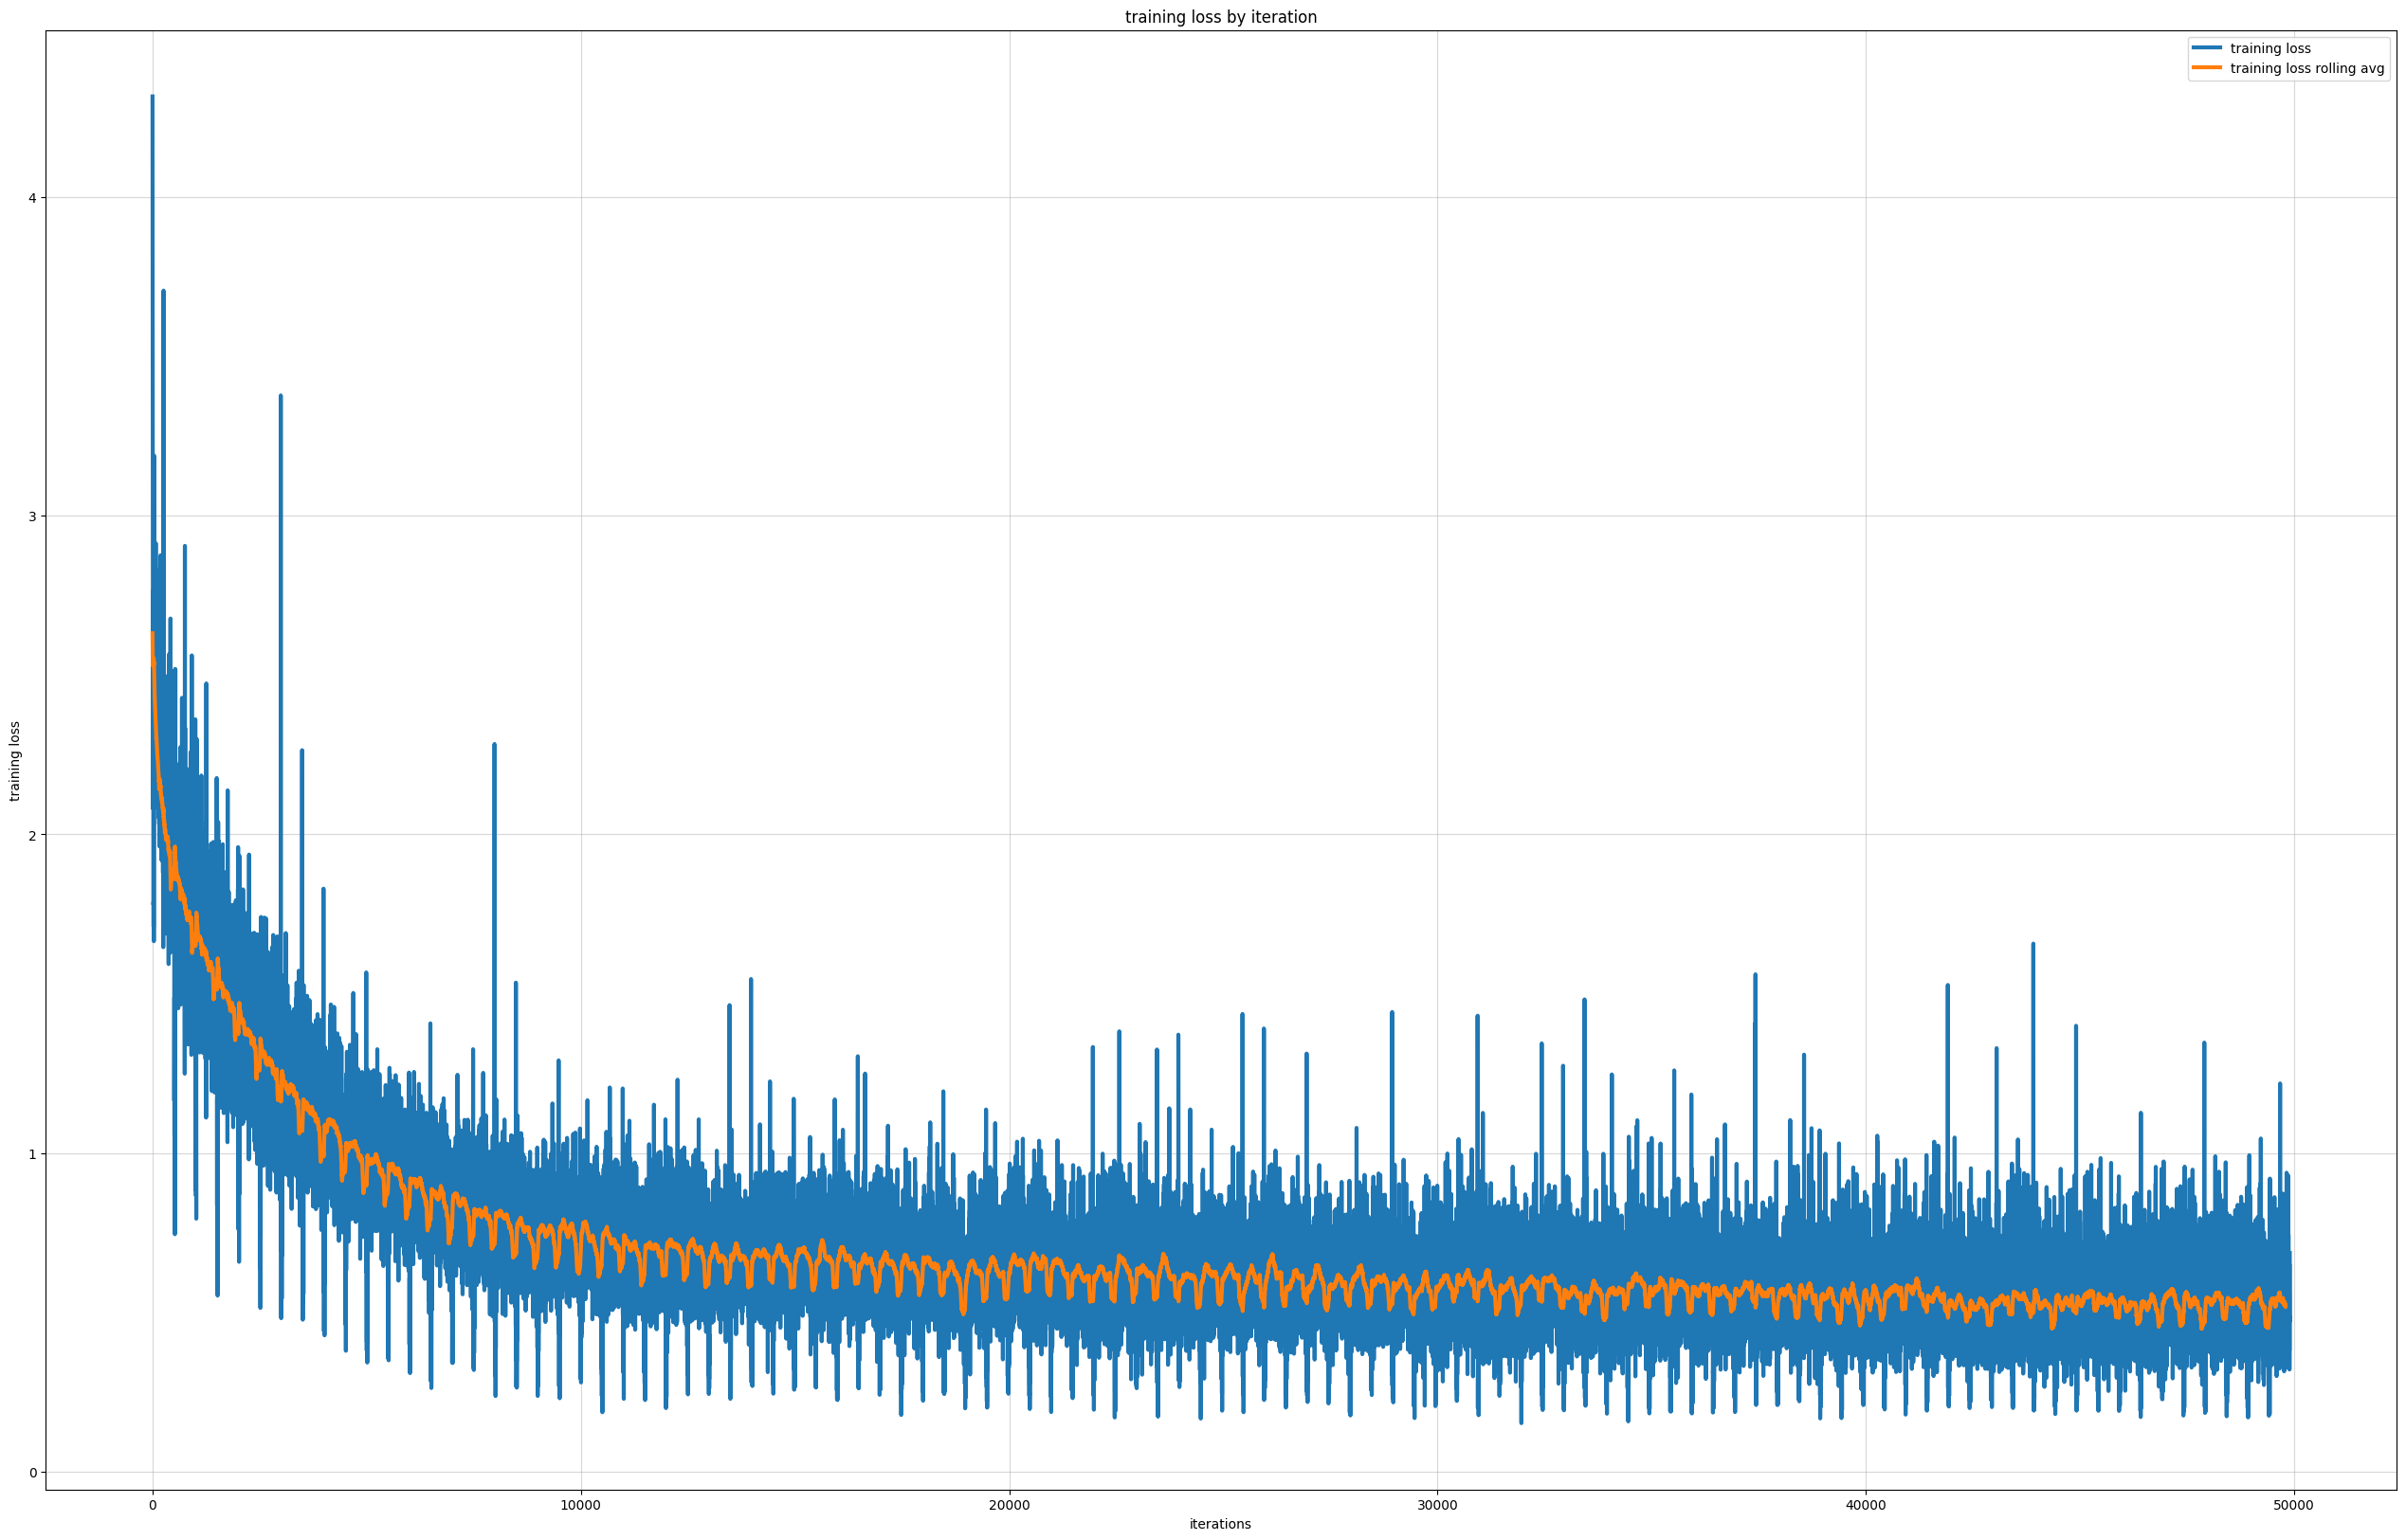

In [68]:
# Plot the training loss and rolling mean training loss with respect to iterations
# Feel free to change the window size
plt.figure(figsize = (32, 20))

plt.plot(training_loss, linewidth = 3, label = 'training loss')
plt.plot(np.convolve(training_loss, np.ones(100), 'valid') / 100,
         linewidth = 3, label = 'training loss rolling avg')
plt.ylabel("training loss")
plt.xlabel("iterations")
plt.grid(alpha = 0.5)
plt.legend()
plt.title("training loss by iteration")